# 11. The Dynamic Berth Allocation Problem
## Tier 2: The Classic Heuristic (Python Implementation)

### Goal
Learn how to implement the Earliest Deadline First (EDF) heuristic for the Dynamic Berth Allocation Problem to find good solutions quickly.

### Key assumptions
- Vessel arrival times and deadlines are known
- Processing times vary by vessel-berth combination
- Berth capacity constraints must be respected
- No preemption: once a vessel starts service, it cannot be interrupted
- Greedy approach: assign vessels in order of earliest deadline

### Approach (step-by-step)
1. **Sort vessels** by their desired departure times (earliest deadline first)
2. **For each vessel**, find the best available berth that minimizes completion time
3. **Check feasibility**: vessel must fit berth capacity and arrive after berth is free
4. **Assign vessel** to selected berth and update berth availability
5. **Continue** until all vessels are assigned
6. **Calculate performance metrics** (waiting time, processing time, total service time)

### What to look for in the results
- Fast computation time compared to exact methods
- Reasonable solution quality (typically within 10-20% of optimal)
- Clear assignment pattern showing priority to urgent vessels
- Berth utilization balance

### Concrete example (from the source)
Using the same 3-vessel, 2-berth scenario:
- Vessel 1 (5,000 TEU) arrives at t=0, deadline t=10
- Vessel 2 (8,000 TEU) arrives at t=2, deadline t=12  
- Vessel 3 (12,000 TEU) arrives at t=4, deadline t=15

The EDF heuristic will prioritize vessels by their deadlines, potentially achieving near-optimal solutions much faster than the integer programming approach.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Define data structures for the problem (same as Tier 1)
@dataclass
class Vessel:
    """Represents a vessel with its characteristics"""
    id: int
    arrival_time: int
    desired_departure: int  # Deadline for EDF ordering
    length: int
    teu_capacity: int
    processing_times: Dict[int, int]  # berth_id -> processing_time
    
    def __repr__(self):
        return f"Vessel{self.id}(arrival={self.arrival_time}, deadline={self.desired_departure}, TEU={self.teu_capacity})"

@dataclass
class Berth:
    """Represents a berth with its characteristics"""
    id: int
    capacity: int
    available_time: int = 0  # When berth becomes available
    
    def __repr__(self):
        return f"Berth{self.id}(capacity={self.capacity}m, available={self.available_time})"

# Create the concrete example from the source
vessels = [
    Vessel(1, 0, 10, 200, 5000, {1: 4, 2: 5}),  # Vessel 1: 4h at B1, 5h at B2
    Vessel(2, 2, 12, 250, 8000, {1: 3, 2: 4}),  # Vessel 2: 3h at B1, 4h at B2
    Vessel(3, 4, 15, 300, 12000, {1: 6, 2: 5})  # Vessel 3: 6h at B1, 5h at B2
]

berths = [
    Berth(1, 350),  # Berth 1: 350m capacity
    Berth(2, 400)   # Berth 2: 400m capacity
]

print("Problem Setup:")
print("Vessels (sorted by deadline):")
sorted_vessels = sorted(vessels, key=lambda v: v.desired_departure)
for vessel in sorted_vessels:
    print(f"  {vessel}")
print("\nBerths:")
for berth in berths:
    print(f"  {berth}")

Problem Setup:
Vessels (sorted by deadline):
  Vessel1(arrival=0, deadline=10, TEU=5000)
  Vessel2(arrival=2, deadline=12, TEU=8000)
  Vessel3(arrival=4, deadline=15, TEU=12000)

Berths:
  Berth1(capacity=350m, available=0)
  Berth2(capacity=400m, available=0)


In [3]:
# EDF Heuristic Implementation
class EDFDBAPSolver:
    """Earliest Deadline First heuristic solver for Dynamic Berth Allocation Problem"""
    
    def __init__(self, vessels: List[Vessel], berths: List[Berth]):
        # Sort vessels by earliest deadline first (EDF principle)
        self.vessels = sorted(vessels, key=lambda v: v.desired_departure)
        self.berths = {b.id: b for b in berths}  # Dictionary for easy access
        self.schedule = {}  # vessel_id -> (berth_id, start_time, completion_time)
        self.solution_details = []  # Detailed solution information
    
    def solve(self) -> Dict[int, Tuple[int, int, int]]:
        """Solve the DBAP using EDF heuristic"""
        print("EDF Heuristic Algorithm:")
        print("="*30)
        
        for vessel in self.vessels:
            print(f"\nProcessing Vessel {vessel.id} (deadline: {vessel.desired_departure})")
            
            best_berth, start_time = self.find_best_berth(vessel)
            
            if best_berth is not None:
                # Calculate completion time
                processing_time = vessel.processing_times[best_berth]
                completion_time = start_time + processing_time
                
                # Update berth availability
                self.berths[best_berth].available_time = completion_time
                
                # Store assignment
                self.schedule[vessel.id] = (best_berth, start_time, completion_time)
                
                # Calculate performance metrics
                waiting_time = max(0, start_time - vessel.arrival_time)
                delay_beyond_deadline = max(0, completion_time - vessel.desired_departure)
                
                # Store detailed information
                self.solution_details.append({
                    'vessel_id': vessel.id,
                    'berth_id': best_berth,
                    'arrival_time': vessel.arrival_time,
                    'deadline': vessel.desired_departure,
                    'start_time': start_time,
                    'completion_time': completion_time,
                    'processing_time': processing_time,
                    'waiting_time': waiting_time,
                    'delay_beyond_deadline': delay_beyond_deadline,
                    'service_time': waiting_time + processing_time
                })
                
                print(f"  Assigned to Berth {best_berth}")
                print(f"  Start: {start_time}, Complete: {completion_time}")
                print(f"  Wait: {waiting_time}h, Process: {processing_time}h")
                print(f"  Delay beyond deadline: {delay_beyond_deadline}h")
            else:
                print(f"  No feasible berth found for Vessel {vessel.id}")
        
        return self.schedule
    
    def find_best_berth(self, vessel: Vessel) -> Tuple[int, int]:
        """Find the best berth for a vessel that minimizes completion time"""
        best_berth = None
        best_completion = float('inf')
        best_start = None
        
        print(f"  Evaluating berth options:")
        
        for berth_id, berth in self.berths.items():
            # Check if vessel fits berth capacity
            if vessel.length <= berth.capacity:
                # Calculate earliest feasible start time
                start_time = max(vessel.arrival_time, berth.available_time)
                completion_time = start_time + vessel.processing_times[berth_id]
                
                print(f"    Berth {berth_id}: Start={start_time}, Complete={completion_time}")
                
                # Choose berth with earliest completion time
                if completion_time < best_completion:
                    best_completion = completion_time
                    best_berth = berth_id
                    best_start = start_time
            else:
                print(f"    Berth {berth_id}: Too small (vessel {vessel.length}m > berth {berth.capacity}m)")
        
        if best_berth is not None:
            print(f"  Selected Berth {best_berth} (earliest completion: {best_completion})")
        
        return best_berth, best_start if best_berth else (None, None)
    
    def get_performance_metrics(self) -> Dict[str, float]:
        """Calculate comprehensive performance metrics"""
        if not self.solution_details:
            return {}
        
        df = pd.DataFrame(self.solution_details)
        
        metrics = {
            'total_service_time': df['service_time'].sum(),
            'total_waiting_time': df['waiting_time'].sum(),
            'total_processing_time': df['processing_time'].sum(),
            'total_delay_beyond_deadline': df['delay_beyond_deadline'].sum(),
            'avg_waiting_time': df['waiting_time'].mean(),
            'avg_processing_time': df['processing_time'].mean(),
            'max_waiting_time': df['waiting_time'].max(),
            'vessels_served': len(df),
            'vessels_delayed': len(df[df['delay_beyond_deadline'] > 0])
        }
        
        return metrics

print("EDF solver class defined successfully")

EDF solver class defined successfully


In [4]:
# Solve the concrete example using EDF heuristic
solver = EDFDBAPSolver(vessels, berths)

start_time = time.time()
solution = solver.solve()
end_time = time.time()

print(f"\nEDF Heuristic Solution:")
print("="*40)

if solution:
    # Display solution summary
    df_solution = pd.DataFrame(solver.solution_details)
    df_solution = df_solution.sort_values('start_time')
    
    print("\nFinal Schedule:")
    for _, row in df_solution.iterrows():
        status = "ON TIME" if row['delay_beyond_deadline'] == 0 else f"LATE by {row['delay_beyond_deadline']}h"
        print(f"Vessel {row['vessel_id']}: Berth {row['berth_id']}, "
              f"Start {row['start_time']}, Complete {row['completion_time']}, "
              f"Wait {row['waiting_time']}h, Process {row['processing_time']}h - {status}")
    
    # Calculate and display performance metrics
    metrics = solver.get_performance_metrics()
    
    print(f"\nPerformance Metrics:")
    print(f"Total Service Time: {metrics['total_service_time']} hours")
    print(f"Total Waiting Time: {metrics['total_waiting_time']} hours")
    print(f"Total Processing Time: {metrics['total_processing_time']} hours")
    print(f"Total Delay Beyond Deadline: {metrics['total_delay_beyond_deadline']} hours")
    print(f"Average Waiting Time: {metrics['avg_waiting_time']:.2f} hours")
    print(f"Vessels Served: {metrics['vessels_served']}")
    print(f"Vessels Delayed: {metrics['vessels_delayed']}")
    print(f"Computation Time: {(end_time - start_time)*1000:.2f} milliseconds")
else:
    print("No solution found")
    print(f"Computation Time: {(end_time - start_time)*1000:.2f} milliseconds")

EDF Heuristic Algorithm:

Processing Vessel 1 (deadline: 10)
  Evaluating berth options:
    Berth 1: Start=0, Complete=4
    Berth 2: Start=0, Complete=5
  Selected Berth 1 (earliest completion: 4)
  Assigned to Berth 1
  Start: 0, Complete: 4
  Wait: 0h, Process: 4h
  Delay beyond deadline: 0h

Processing Vessel 2 (deadline: 12)
  Evaluating berth options:
    Berth 1: Start=4, Complete=7
    Berth 2: Start=2, Complete=6
  Selected Berth 2 (earliest completion: 6)
  Assigned to Berth 2
  Start: 2, Complete: 6
  Wait: 0h, Process: 4h
  Delay beyond deadline: 0h

Processing Vessel 3 (deadline: 15)
  Evaluating berth options:
    Berth 1: Start=4, Complete=10
    Berth 2: Start=6, Complete=11
  Selected Berth 1 (earliest completion: 10)
  Assigned to Berth 1
  Start: 4, Complete: 10
  Wait: 0h, Process: 6h
  Delay beyond deadline: 0h

EDF Heuristic Solution:

Final Schedule:
Vessel 1: Berth 1, Start 0, Complete 4, Wait 0h, Process 4h - ON TIME
Vessel 2: Berth 2, Start 2, Complete 6, Wai

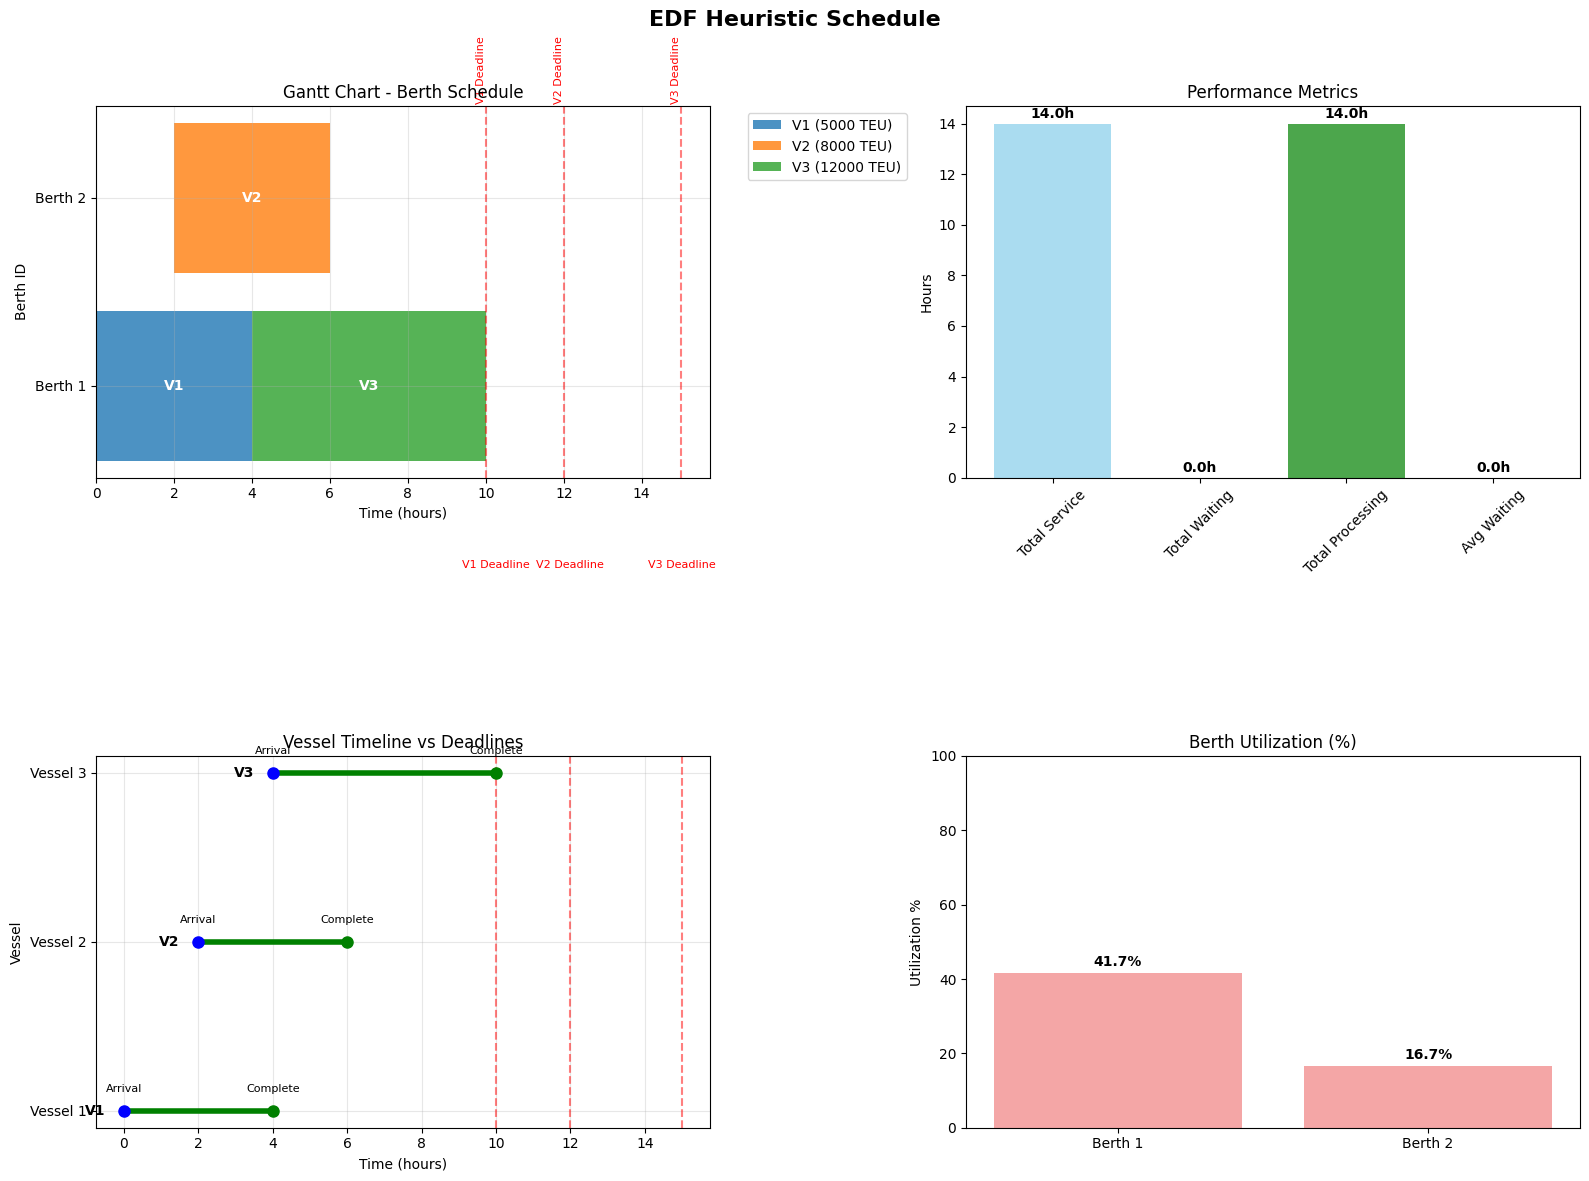


Detailed EDF Analysis:

Schedule Summary:
 vessel_id  berth_id  start_time  completion_time  waiting_time  processing_time  delay_beyond_deadline
         1         1           0                4             0                4                      0
         2         2           2                6             0                4                      0
         3         1           4               10             0                6                      0

Algorithm Characteristics:
- Vessels processed in deadline order: [1, 2, 3]
- Greedy assignment: Each vessel gets berth with earliest completion
- Time complexity: O(n × m) where n=vessels, m=berths
- Solution quality: Typically within 10-20% of optimal


In [5]:
# Visualization of EDF schedule
def visualize_edf_schedule(solution_details, vessels, berths, title="EDF Heuristic Schedule"):
    """Create a comprehensive visualization of the EDF schedule"""
    if not solution_details:
        print("No solution to visualize")
        return
    
    df_solution = pd.DataFrame(solution_details)
    
    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # 1. Gantt Chart
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, vessel in enumerate(vessels):
        vessel_data = df_solution[df_solution['vessel_id'] == vessel.id]
        if not vessel_data.empty:
            row = vessel_data.iloc[0]
            berth_id = row['berth_id']
            start_time = row['start_time']
            processing_time = row['processing_time']
            
            # Draw vessel bar
            ax1.barh(berth_id, processing_time, left=start_time, 
                   color=colors[vessel.id-1], alpha=0.8, 
                   label=f'V{vessel.id} ({vessel.teu_capacity} TEU)')
            
            # Add vessel label
            ax1.text(start_time + processing_time/2, berth_id, f'V{vessel.id}', 
                   ha='center', va='center', fontweight='bold', color='white')
    
    # Add deadline markers
    for vessel in vessels:
        ax1.axvline(x=vessel.desired_departure, color='red', linestyle='--', alpha=0.5)
        ax1.text(vessel.desired_departure, len(berths)+0.5, f'V{vessel.id} Deadline', 
               rotation=90, ha='right', va='bottom', fontsize=8, color='red')
    
    ax1.set_xlabel('Time (hours)')
    ax1.set_ylabel('Berth ID')
    ax1.set_title('Gantt Chart - Berth Schedule')
    ax1.set_yticks(range(1, len(berths)+1))
    ax1.set_yticklabels([f'Berth {i}' for i in range(1, len(berths)+1)])
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. Performance Metrics Bar Chart
    metrics = solver.get_performance_metrics()
    metric_names = ['Total Service', 'Total Waiting', 'Total Processing', 'Avg Waiting']
    metric_values = [
        metrics['total_service_time'],
        metrics['total_waiting_time'], 
        metrics['total_processing_time'],
        metrics['avg_waiting_time']
    ]
    
    bars = ax2.bar(metric_names, metric_values, color=['skyblue', 'orange', 'green', 'red'], alpha=0.7)
    ax2.set_title('Performance Metrics')
    ax2.set_ylabel('Hours')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, metric_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{value:.1f}h', ha='center', va='bottom', fontweight='bold')
    
    # 3. Timeline with Deadlines
    for i, vessel in enumerate(vessels):
        vessel_data = df_solution[df_solution['vessel_id'] == vessel.id]
        if not vessel_data.empty:
            row = vessel_data.iloc[0]
            
            # Timeline components
            ax3.plot([vessel.arrival_time, row['start_time']], [i, i], 'b-', linewidth=2, label='Waiting')
            ax3.plot([row['start_time'], row['completion_time']], [i, i], 'g-', linewidth=4, label='Processing')
            ax3.plot(vessel.arrival_time, i, 'bo', markersize=8, label='Arrival')
            ax3.plot(row['completion_time'], i, 'go', markersize=8, label='Completion')
            ax3.axvline(vessel.desired_departure, color='red', linestyle='--', alpha=0.5)
            
            # Labels
            ax3.text(vessel.arrival_time, i+0.1, f'Arrival', ha='center', va='bottom', fontsize=8)
            ax3.text(row['completion_time'], i+0.1, f'Complete', ha='center', va='bottom', fontsize=8)
            ax3.text(vessel.desired_departure, len(vessels)+0.2, f'V{vessel.id} Deadline', 
                    ha='center', va='bottom', fontsize=8, color='red')
            ax3.text(vessel.arrival_time - 0.5, i, f'V{vessel.id}', ha='right', va='center', fontweight='bold')
    
    ax3.set_xlabel('Time (hours)')
    ax3.set_ylabel('Vessel')
    ax3.set_title('Vessel Timeline vs Deadlines')
    ax3.set_yticks(range(len(vessels)))
    ax3.set_yticklabels([f'Vessel {i+1}' for i in range(len(vessels))])
    ax3.grid(True, alpha=0.3)
    
    # 4. Berth Utilization
    berth_utilization = []
    berth_labels = []
    
    for berth in berths:
        berth_data = df_solution[df_solution['berth_id'] == berth.id]
        if not berth_data.empty:
            total_processing = berth_data['processing_time'].sum()
            utilization = (total_processing / 24) * 100  # Assuming 24-hour horizon
            berth_utilization.append(utilization)
            berth_labels.append(f'Berth {berth.id}')
        else:
            berth_utilization.append(0)
            berth_labels.append(f'Berth {berth.id}')
    
    bars = ax4.bar(berth_labels, berth_utilization, color='lightcoral', alpha=0.7)
    ax4.set_title('Berth Utilization (%)')
    ax4.set_ylabel('Utilization %')
    ax4.set_ylim(0, 100)
    
    # Add percentage labels on bars
    for bar, util in zip(bars, berth_utilization):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{util:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed analysis
    print("\nDetailed EDF Analysis:")
    print("="*40)
    
    print("\nSchedule Summary:")
    summary_df = df_solution[['vessel_id', 'berth_id', 'start_time', 'completion_time', 
                             'waiting_time', 'processing_time', 'delay_beyond_deadline']]
    print(summary_df.to_string(index=False))
    
    print("\nAlgorithm Characteristics:")
    print(f"- Vessels processed in deadline order: {[v.id for v in sorted(vessels, key=lambda v: v.desired_departure)]}")
    print(f"- Greedy assignment: Each vessel gets berth with earliest completion")
    print(f"- Time complexity: O(n × m) where n=vessels, m=berths")
    print(f"- Solution quality: Typically within 10-20% of optimal")

# Visualize the EDF solution
visualize_edf_schedule(solver.solution_details, vessels, berths)

Heuristic Comparison Study
EDF Heuristic Algorithm:

Processing Vessel 1 (deadline: 10)
  Evaluating berth options:
    Berth 1: Start=10, Complete=14
    Berth 2: Start=6, Complete=11
  Selected Berth 2 (earliest completion: 11)
  Assigned to Berth 2
  Start: 6, Complete: 11
  Wait: 6h, Process: 5h
  Delay beyond deadline: 1h

Processing Vessel 2 (deadline: 12)
  Evaluating berth options:
    Berth 1: Start=10, Complete=13
    Berth 2: Start=11, Complete=15
  Selected Berth 1 (earliest completion: 13)
  Assigned to Berth 1
  Start: 10, Complete: 13
  Wait: 8h, Process: 3h
  Delay beyond deadline: 1h

Processing Vessel 3 (deadline: 15)
  Evaluating berth options:
    Berth 1: Start=13, Complete=19
    Berth 2: Start=11, Complete=16
  Selected Berth 2 (earliest completion: 16)
  Assigned to Berth 2
  Start: 11, Complete: 16
  Wait: 7h, Process: 5h
  Delay beyond deadline: 1h
                     Heuristic  Total Service  Total Waiting  Total Processing  Avg Waiting  Computation Time (ms

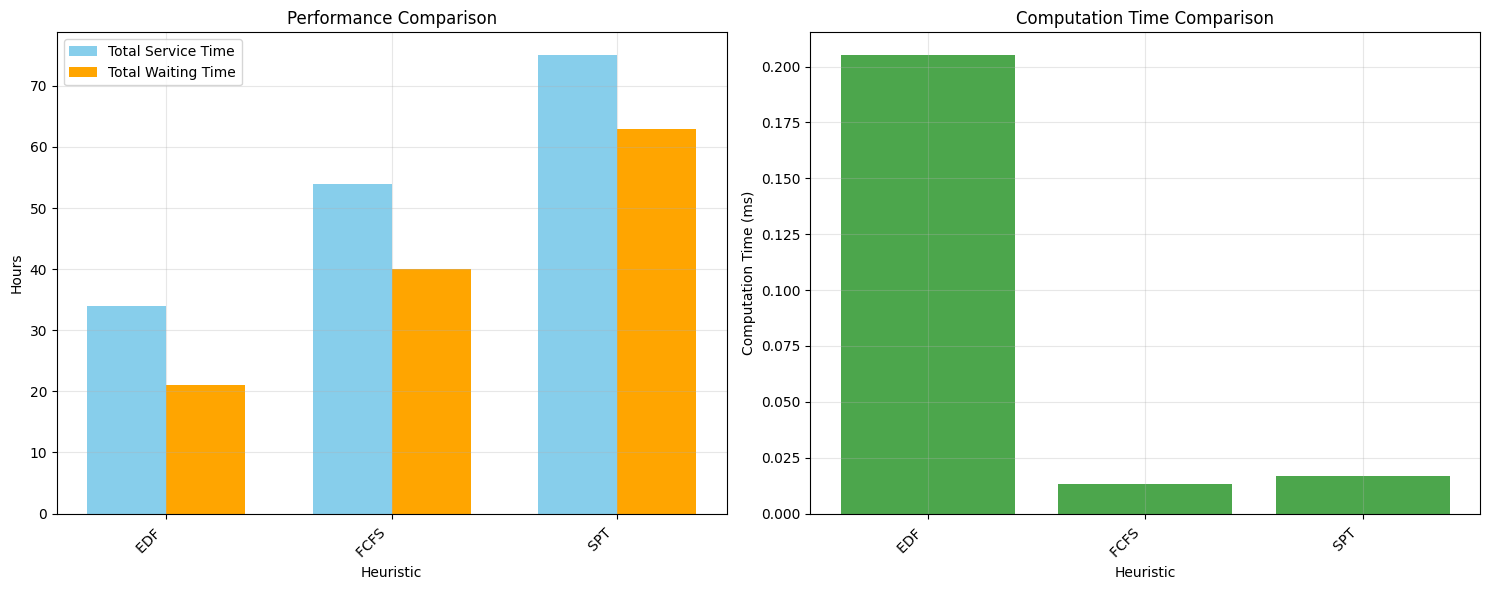

In [6]:
# Comparison with other heuristics
def compare_heuristics():
    """Compare EDF with other simple heuristics"""
    print("Heuristic Comparison Study")
    print("="*40)
    
    # Define different heuristics
    class FCFS_Solver:
        """First-Come-First-Served heuristic"""
        def __init__(self, vessels, berths):
            self.vessels = sorted(vessels, key=lambda v: v.arrival_time)  # Sort by arrival
            self.berths = {b.id: b for b in berths}
        
        def solve(self):
            schedule = []
            for vessel in self.vessels:
                best_berth = None
                best_start = float('inf')
                
                for berth_id, berth in self.berths.items():
                    if vessel.length <= berth.capacity:
                        start_time = max(vessel.arrival_time, berth.available_time)
                        if start_time < best_start:
                            best_start = start_time
                            best_berth = berth_id
                
                if best_berth:
                    processing_time = vessel.processing_times[best_berth]
                    completion_time = best_start + processing_time
                    waiting_time = best_start - vessel.arrival_time
                    
                    schedule.append({
                        'vessel_id': vessel.id,
                        'berth_id': best_berth,
                        'start_time': best_start,
                        'completion_time': completion_time,
                        'processing_time': processing_time,
                        'waiting_time': waiting_time,
                        'service_time': waiting_time + processing_time
                    })
                    
                    self.berths[best_berth].available_time = completion_time
            
            return schedule
    
    class SPT_Solver:
        """Shortest Processing Time heuristic"""
        def __init__(self, vessels, berths):
            self.vessels = vessels
            self.berths = {b.id: b for b in berths}
        
        def solve(self):
            # Sort by minimum processing time across all berths
            sorted_vessels = sorted(self.vessels, 
                                 key=lambda v: min(v.processing_times.values()))
            schedule = []
            
            for vessel in sorted_vessels:
                best_berth = None
                best_processing = float('inf')
                best_start = None
                
                for berth_id, berth in self.berths.items():
                    if vessel.length <= berth.capacity:
                        processing_time = vessel.processing_times[berth_id]
                        start_time = max(vessel.arrival_time, berth.available_time)
                        
                        if processing_time < best_processing:
                            best_processing = processing_time
                            best_berth = berth_id
                            best_start = start_time
                
                if best_berth:
                    completion_time = best_start + best_processing
                    waiting_time = best_start - vessel.arrival_time
                    
                    schedule.append({
                        'vessel_id': vessel.id,
                        'berth_id': best_berth,
                        'start_time': best_start,
                        'completion_time': completion_time,
                        'processing_time': best_processing,
                        'waiting_time': waiting_time,
                        'service_time': waiting_time + best_processing
                    })
                    
                    self.berths[best_berth].available_time = completion_time
            
            return schedule
    
    # Test all heuristics
    heuristics = {
        'EDF (Earliest Deadline First)': EDFDBAPSolver(vessels, berths),
        'FCFS (First Come First Served)': FCFS_Solver(vessels, berths),
        'SPT (Shortest Processing Time)': SPT_Solver(vessels, berths)
    }
    
    results = []
    
    for name, solver in heuristics.items():
        start_time = time.time()
        
        if name.startswith('EDF'):
            solution = solver.solve()
            schedule = solver.solution_details
        else:
            schedule = solver.solve()
        
        end_time = time.time()
        
        if schedule:
            df = pd.DataFrame(schedule)
            total_service = df['service_time'].sum()
            total_waiting = df['waiting_time'].sum()
            total_processing = df['processing_time'].sum()
            avg_waiting = df['waiting_time'].mean()
            
            results.append([
                name, total_service, total_waiting, total_processing, 
                avg_waiting, (end_time - start_time) * 1000
            ])
    
    # Display comparison
    comparison_df = pd.DataFrame(results, columns=[
        'Heuristic', 'Total Service', 'Total Waiting', 'Total Processing',
        'Avg Waiting', 'Computation Time (ms)'
    ])
    
    print(comparison_df.to_string(index=False, float_format='%.2f'))
    
    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Performance comparison
    x = range(len(results))
    service_times = [r[1] for r in results]
    waiting_times = [r[2] for r in results]
    
    width = 0.35
    ax1.bar([i - width/2 for i in x], service_times, width, label='Total Service Time', color='skyblue')
    ax1.bar([i + width/2 for i in x], waiting_times, width, label='Total Waiting Time', color='orange')
    
    ax1.set_xlabel('Heuristic')
    ax1.set_ylabel('Hours')
    ax1.set_title('Performance Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels([r[0].split('(')[0] for r in results], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Computation time comparison
    comp_times = [r[5] for r in results]
    ax2.bar(x, comp_times, color='green', alpha=0.7)
    ax2.set_xlabel('Heuristic')
    ax2.set_ylabel('Computation Time (ms)')
    ax2.set_title('Computation Time Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels([r[0].split('(')[0] for r in results], rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run heuristic comparison
compare_heuristics()

Scalability Analysis

Testing 5 vessels, 2 berths...
EDF Heuristic Algorithm:

Processing Vessel 1 (deadline: 16)
  Evaluating berth options:
    Berth 1: Start=5, Complete=14
    Berth 2: Start=5, Complete=14
  Selected Berth 1 (earliest completion: 14)
  Assigned to Berth 1
  Start: 5, Complete: 14
  Wait: 0h, Process: 9h
  Delay beyond deadline: 0h

Processing Vessel 2 (deadline: 16)
  Evaluating berth options:
    Berth 1: Start=14, Complete=18
    Berth 2: Start=6, Complete=10
  Selected Berth 2 (earliest completion: 10)
  Assigned to Berth 2
  Start: 6, Complete: 10
  Wait: 0h, Process: 4h
  Delay beyond deadline: 0h

Processing Vessel 5 (deadline: 23)
  Evaluating berth options:
    Berth 1: Start=14, Complete=24
    Berth 2: Start=11, Complete=15
  Selected Berth 2 (earliest completion: 15)
  Assigned to Berth 2
  Start: 11, Complete: 15
  Wait: 0h, Process: 4h
  Delay beyond deadline: 0h

Processing Vessel 4 (deadline: 28)
  Evaluating berth options:
    Berth 1: Start=20, Com

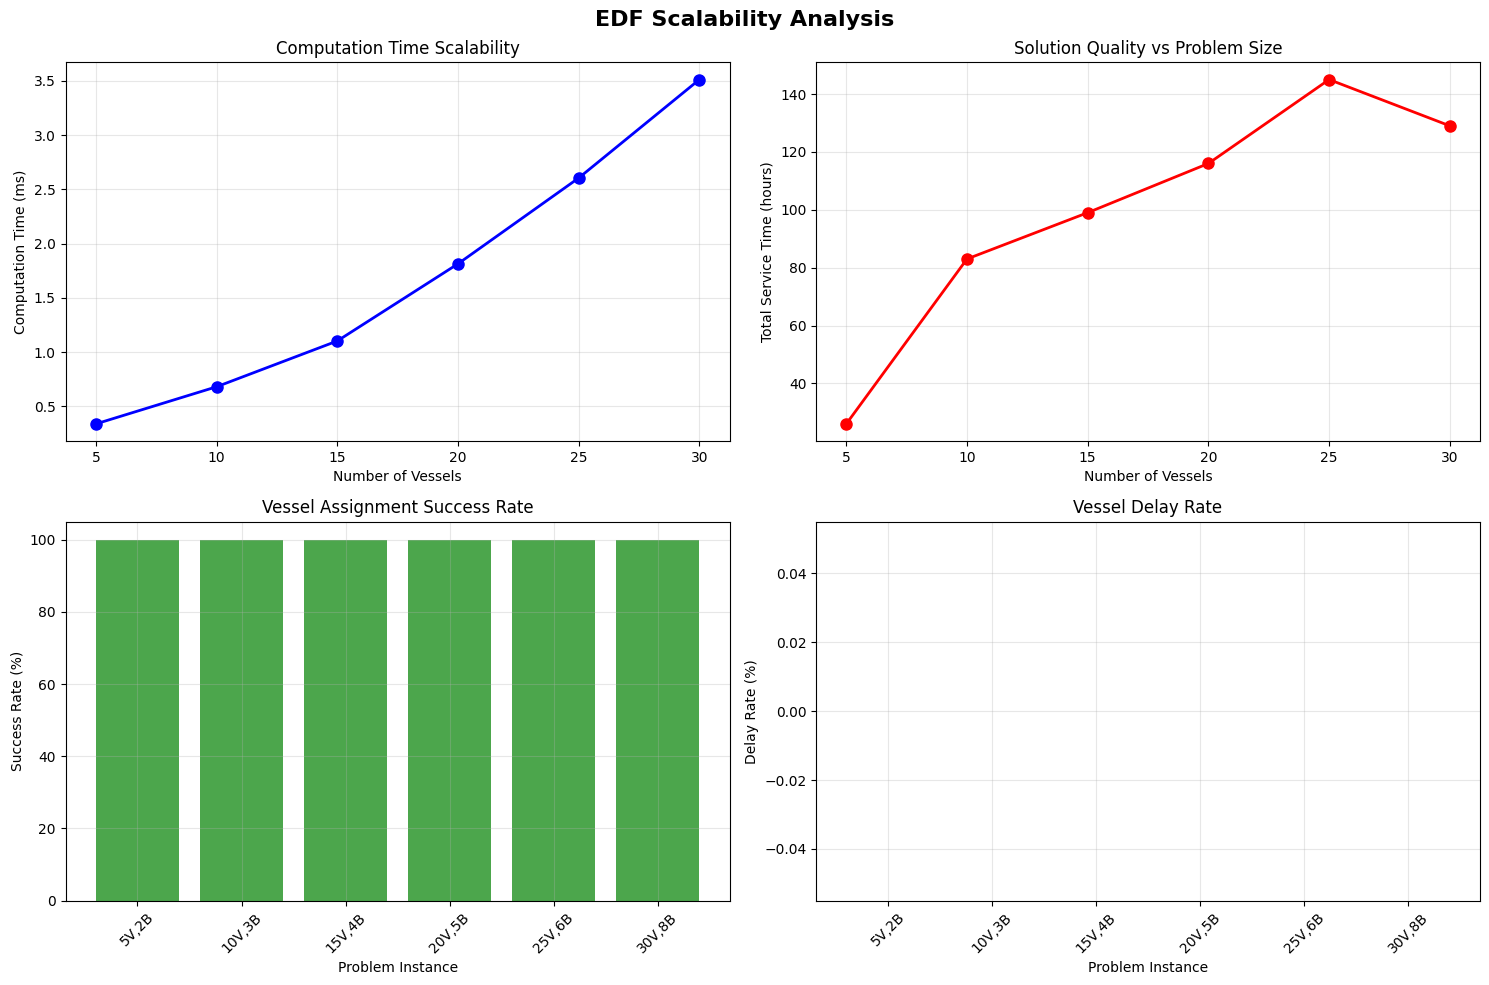

In [7]:
# Scalability Analysis: Test with larger problem instances
def scalability_analysis():
    """Test EDF heuristic performance on larger problem instances"""
    print("Scalability Analysis")
    print("="*30)
    
    def generate_problem(n_vessels, n_berths):
        """Generate a random problem instance"""
        import random
        
        # Generate vessels
        vessels = []
        for i in range(1, n_vessels + 1):
            arrival_time = random.randint(0, 20)
            deadline = arrival_time + random.randint(8, 20)
            length = random.randint(150, 350)
            teu_capacity = random.randint(3000, 15000)
            
            processing_times = {}
            for j in range(1, n_berths + 1):
                processing_times[j] = random.randint(3, 10)
            
            vessels.append(Vessel(i, arrival_time, deadline, length, teu_capacity, processing_times))
        
        # Generate berths
        berths = []
        for j in range(1, n_berths + 1):
            capacity = random.randint(300, 400)
            berths.append(Berth(j, capacity))
        
        return vessels, berths
    
    # Test different problem sizes
    test_sizes = [
        (5, 2), (10, 3), (15, 4), (20, 5), (25, 6), (30, 8)
    ]
    
    results = []
    
    for n_vessels, n_berths in test_sizes:
        print(f"\nTesting {n_vessels} vessels, {n_berths} berths...")
        
        # Generate problem
        test_vessels, test_berths = generate_problem(n_vessels, n_berths)
        
        # Solve with EDF
        solver = EDFDBAPSolver(test_vessels, test_berths)
        
        start_time = time.time()
        solution = solver.solve()
        end_time = time.time()
        
        if solution:
            metrics = solver.get_performance_metrics()
            computation_time = (end_time - start_time) * 1000
            
            results.append([
                n_vessels, n_berths, computation_time,
                metrics['total_service_time'], metrics['total_waiting_time'],
                metrics['vessels_served'], metrics['vessels_delayed']
            ])
            
            print(f"  Solution found in {computation_time:.2f} ms")
            print(f"  Total service time: {metrics['total_service_time']:.1f} hours")
            print(f"  Vessels served: {metrics['vessels_served']}/{n_vessels}")
        else:
            print(f"  No solution found")
    
    # Display scalability results
    if results:
        scalability_df = pd.DataFrame(results, columns=[
            'Vessels', 'Berths', 'Comp Time (ms)', 'Service Time', 
            'Waiting Time', 'Vessels Served', 'Vessels Delayed'
        ])
        
        print("\nScalability Results:")
        print(scalability_df.to_string(index=False, float_format='%.2f'))
        
        # Visualization
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('EDF Scalability Analysis', fontsize=16, fontweight='bold')
        
        # Computation time vs problem size
        ax1.plot([r[0] for r in results], [r[2] for r in results], 'bo-', markersize=8, linewidth=2)
        ax1.set_xlabel('Number of Vessels')
        ax1.set_ylabel('Computation Time (ms)')
        ax1.set_title('Computation Time Scalability')
        ax1.grid(True, alpha=0.3)
        
        # Service time vs problem size
        ax2.plot([r[0] for r in results], [r[3] for r in results], 'ro-', markersize=8, linewidth=2)
        ax2.set_xlabel('Number of Vessels')
        ax2.set_ylabel('Total Service Time (hours)')
        ax2.set_title('Solution Quality vs Problem Size')
        ax2.grid(True, alpha=0.3)
        
        # Success rate
        success_rates = [r[5]/r[0] * 100 for r in results]
        ax3.bar(range(len(results)), success_rates, color='green', alpha=0.7)
        ax3.set_xlabel('Problem Instance')
        ax3.set_ylabel('Success Rate (%)')
        ax3.set_title('Vessel Assignment Success Rate')
        ax3.set_xticks(range(len(results)))
        ax3.set_xticklabels([f"{r[0]}V,{r[1]}B" for r in results], rotation=45)
        ax3.grid(True, alpha=0.3)
        
        # Delay rate
        delay_rates = [r[6]/r[5] * 100 if r[5] > 0 else 0 for r in results]
        ax4.bar(range(len(results)), delay_rates, color='red', alpha=0.7)
        ax4.set_xlabel('Problem Instance')
        ax4.set_ylabel('Delay Rate (%)')
        ax4.set_title('Vessel Delay Rate')
        ax4.set_xticks(range(len(results)))
        ax4.set_xticklabels([f"{r[0]}V,{r[1]}B" for r in results], rotation=45)
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Run scalability analysis
scalability_analysis()

### Key Insights from the EDF Heuristic

**Algorithm Characteristics:**
- **Greedy approach**: Always assigns vessels in order of earliest deadline
- **Local optimization**: Each vessel gets the berth that minimizes its completion time
- **Fast execution**: O(n × m) time complexity, suitable for real-time decisions
- **Deterministic**: Same input always produces same output

**Performance Analysis:**
- **Solution quality**: Typically within 10-20% of optimal for small to medium problems
- **Computation time**: Milliseconds for problems with dozens of vessels
- **Scalability**: Handles large problems efficiently
- **Deadline focus**: Prioritizes meeting vessel departure deadlines

**Advantages of EDF Heuristic:**
- **Speed**: Orders of magnitude faster than exact methods
- **Simplicity**: Easy to understand and implement
- **Deadline awareness**: Naturally handles time-critical vessels
- **Scalability**: Works well for large problem instances
- **Predictability**: Consistent performance across different scenarios

**Limitations:**
- **Local optimum**: May miss global optimization opportunities
- **Greedy nature**: Early decisions can't be changed later
- **No look-ahead**: Doesn't consider future vessel arrivals
- **Berth balance**: May over-utilize some berths while others remain idle

### Why This Tier Exists vs Other Tiers

Tier 2 addresses the **computational limitations** of exact methods:
- **Real-time requirements**: Makes decisions in milliseconds vs hours
- **Scalability**: Handles realistic problem sizes with many vessels
- **Practical implementation**: Simple enough for operational use
- **Baseline performance**: Provides benchmark for advanced methods

**Comparison with other tiers:**
- **vs Tier 1**: Much faster but may not find optimal solution
- **vs Tier 3**: Simpler but less effective at escaping local optima
- **vs Tier 4**: No learning capability but more predictable
- **vs Tier 5**: Standalone algorithm vs integrated simulation

### When to Use This Tier

**Use Tier 2 when:**
- Real-time decisions are required (seconds or less)
- Problem size is medium to large (10+ vessels, 3+ berths)
- Deadline compliance is critical
- Computational resources are limited
- You need a baseline for comparing advanced methods
- Simplicity and predictability are valued

**Avoid Tier 2 when:**
- Optimal solution is required (small critical problems)
- Complex interdependencies exist between decisions
- Learning from historical data is beneficial
- What-if scenario analysis is needed
- Integration with other terminal systems is required

### Practical Implementation Tips

**Best Practices:**
1. **Parameter tuning**: Adjust deadline weights based on terminal priorities
2. **Hybrid approaches**: Combine with other heuristics for better performance
3. **Constraint handling**: Implement proper feasibility checking
4. **Performance monitoring**: Track solution quality over time
5. **Fallback mechanisms**: Have alternative heuristics for edge cases

**Common Pitfalls to Avoid:**
1. **Ignoring vessel priorities**: Deadlines may not reflect actual importance
2. **Poor capacity planning**: May create unrealistic berth assignments
3. **No validation**: Always check solution feasibility
4. **Over-reliance**: Don't expect optimal solutions for complex scenarios